Wards shape: (116, 6)
Wards CRS: EPSG:4326
Settlements shape: (10, 4)


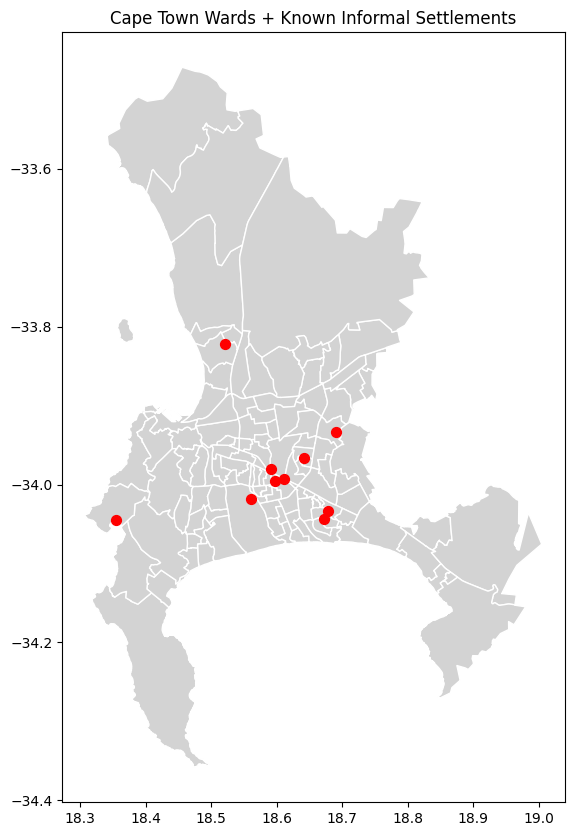

In [6]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# ---- 1. Ward boundaries (Cape Town ArcGIS Hub) ----
wards_url = "https://opendata.arcgis.com/datasets/cctegis::wards.geojson"
wards_gdf = gpd.read_file(wards_url)
print("Wards shape:", wards_gdf.shape)
print("Wards CRS:", wards_gdf.crs)

# ---- 2. Curated informal settlements (known, documented locations) ----
settlements_data = {
    "name": ["Khayelitsha", "Dunoon", "Imizamo Yethu", "Marikana", "QQ Section",
             "Kosovo", "Nyanga", "Philippi", "Delft", "Mfuleni"],
    "latitude": [-34.0333, -33.8214, -34.0450, -33.9930, -34.0432,
                 -33.9950, -33.9800, -34.0180, -33.9670, -33.9330],
    "longitude": [18.6790, 18.5210, 18.3540, 18.6120, 18.6720,
                  18.5980, 18.5920, 18.5610, 18.6420, 18.6900]
}

settlements_df = pd.DataFrame(settlements_data)
settlements_gdf = gpd.GeoDataFrame(
    settlements_df,
    geometry=[Point(xy) for xy in zip(settlements_df["longitude"], settlements_df["latitude"])],
    crs="EPSG:4326"
)
print("Settlements shape:", settlements_gdf.shape)

# ---- Quick sanity plot ----
fig, ax = plt.subplots(figsize=(10, 10))
wards_gdf.to_crs(epsg=4326).plot(ax=ax, color='lightgrey', edgecolor='white')
settlements_gdf.plot(ax=ax, color='red', markersize=50)
plt.title("Cape Town Wards + Known Informal Settlements")
plt.show()

In [7]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# ---- 1. Ward boundaries ----
wards_url = "https://opendata.arcgis.com/datasets/cctegis::wards.geojson"
wards_gdf = gpd.read_file(wards_url)
wards_4326 = wards_gdf.to_crs(epsg=4326)

# ---- 2. Curated informal settlements ----
settlements_data = {
    "name": ["Khayelitsha", "Dunoon", "Imizamo Yethu", "Marikana", "QQ Section",
             "Kosovo", "Nyanga", "Philippi", "Delft", "Mfuleni"],
    "latitude": [-34.0333, -33.8214, -34.0450, -33.9930, -34.0432,
                 -33.9950, -33.9800, -34.0180, -33.9670, -33.9330],
    "longitude": [18.6790, 18.5210, 18.3540, 18.6120, 18.6720,
                  18.5980, 18.5920, 18.5610, 18.6420, 18.6900]
}
settlements_df = pd.DataFrame(settlements_data)
settlements_gdf = gpd.GeoDataFrame(
    settlements_df,
    geometry=[Point(xy) for xy in zip(settlements_df["longitude"], settlements_df["latitude"])],
    crs="EPSG:4326"
)

# ---- 3. Spatial join ----
settlements_with_ward = gpd.sjoin(settlements_gdf, wards_4326, how="left", predicate="within")
print(settlements_with_ward[["name", "WARD_NAME"]])
print()
print("Unmatched settlements (ward = NaN):", settlements_with_ward["WARD_NAME"].isna().sum())

            name WARD_NAME
0    Khayelitsha        93
1         Dunoon       113
2  Imizamo Yethu        74
3       Marikana        36
4     QQ Section        97
5         Kosovo        36
6         Nyanga        22
7       Philippi        43
8          Delft        20
9        Mfuleni        11

Unmatched settlements (ward = NaN): 0


In [8]:
# Add Joe Slovo to the settlements data
new_settlement = pd.DataFrame({
    "name": ["Joe Slovo"],
    "latitude": [-33.9519],
    "longitude": [18.5342]
})

settlements_df = pd.concat([settlements_df, new_settlement], ignore_index=True)

settlements_gdf = gpd.GeoDataFrame(
    settlements_df,
    geometry=[Point(xy) for xy in zip(settlements_df["longitude"], settlements_df["latitude"])],
    crs="EPSG:4326"
)

# Re-run the spatial join with the updated dataset
settlements_with_ward = gpd.sjoin(settlements_gdf, wards_4326, how="left", predicate="within")
print(settlements_with_ward[["name", "WARD_NAME"]])
print()
print("Unmatched settlements (ward = NaN):", settlements_with_ward["WARD_NAME"].isna().sum())

# Updated counts
settlements_per_ward = settlements_with_ward["WARD_NAME"].value_counts().sort_values(ascending=False)
print()
print("Settlements per ward:")
print(settlements_per_ward)

             name WARD_NAME
0     Khayelitsha        93
1          Dunoon       113
2   Imizamo Yethu        74
3        Marikana        36
4      QQ Section        97
5          Kosovo        36
6          Nyanga        22
7        Philippi        43
8           Delft        20
9         Mfuleni        11
10      Joe Slovo        52

Unmatched settlements (ward = NaN): 0

Settlements per ward:
WARD_NAME
36     2
93     1
113    1
74     1
97     1
22     1
43     1
20     1
11     1
52     1
Name: count, dtype: int64


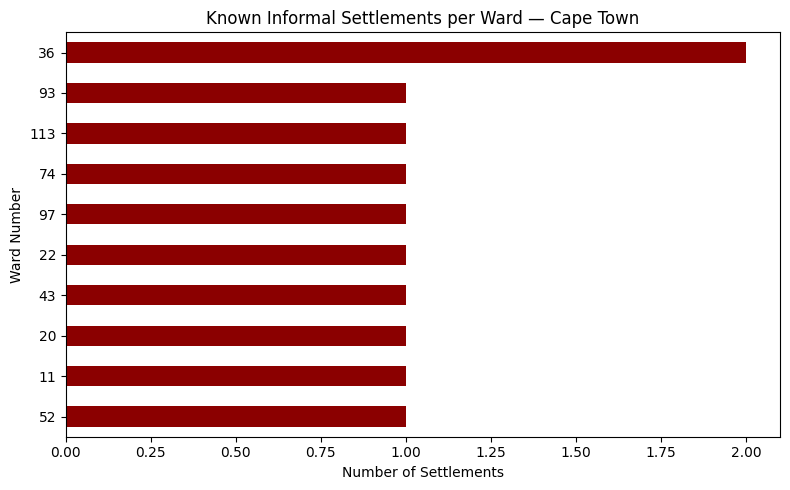

In [9]:
plt.figure(figsize=(8, 5))
settlements_per_ward.plot(kind="barh", color="darkred")
plt.title("Known Informal Settlements per Ward — Cape Town")
plt.xlabel("Number of Settlements")
plt.ylabel("Ward Number")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

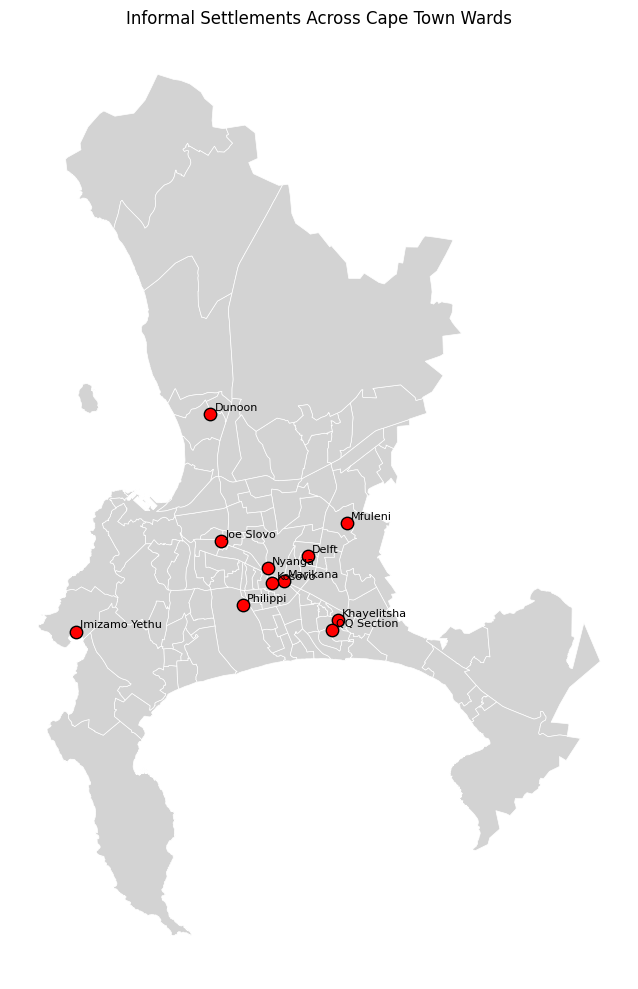

In [10]:

fig, ax = plt.subplots(figsize=(10, 10))
wards_4326.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
settlements_with_ward.plot(ax=ax, color="red", markersize=80, edgecolor="black")

for idx, row in settlements_with_ward.iterrows():
    ax.annotate(row["name"], xy=(row.geometry.x, row.geometry.y),
                xytext=(3, 3), textcoords="offset points", fontsize=8)

plt.title("Informal Settlements Across Cape Town Wards")
plt.axis("off")
plt.tight_layout()
plt.show()

## 📝 Summary & Insights

### What the data shows
- Of the 11 well-documented informal settlements analyzed, all were successfully matched to a Cape Town ward via spatial join, confirming the ward boundary data and settlement coordinates are spatially consistent.
- 10 of 11 wards contain exactly one settlement each. Ward 36 is the only ward with two settlements, Marikana and Kosovo, both located in the Philippi/Cape Flats area.
- The settlements span a wide geographic range, from Dunoon in the north to Mfuleni in the southeast, showing informality is not confined to a single part of the city, but distributed across multiple, disconnected wards.
- Notably, several of the largest and most historically significant settlements in Cape Town, including Khayelitsha, Joe Slovo, and Kosovo, appear in this dataset, each falling into a different ward. This limits any single ward from being read as "the" informal settlement hotspot based on this sample alone.

### Connecting to the datafication framework
This project is a small, practical extension of the datafication argument from my MDSSB-APP-01 paper. How a settlement becomes "visible" in data shapes whether it becomes visible in policy.

- The ward boundary dataset itself is a formal administrative layer, clean, standardized, and easily joinable. The informal settlements, by contrast, don't have an equally authoritative, easily accessible spatial dataset, as this project's own data collection struggles demonstrated firsthand (see Data Sources & Limitations below). That asymmetry mirrors Couldry and Watson's point, that formal, governed spaces are "datafied" by default, while informal spaces require deliberate effort to even appear in a dataset at all.
- A ward level count, like the one this project produces, is a simplification that a policy dashboard might use, but it flattens settlements of very different sizes and populations, such as Kosovo's roughly 6,000 structures compared to a much smaller settlement, into equal, single data points. This is a concrete illustration of how datafication can obscure as much as it reveals. The "1 settlement per ward" pattern looks tidy, but hides massive variation in actual need.

### Limitations
- This is a curated sample of 11 well-documented settlements, not an exhaustive dataset. Cape Town has considerably more informal settlements than are represented here, with estimates running into the hundreds. The findings describe where these known settlements sit relative to ward boundaries, not the full scale or distribution of informality citywide.
- No population, service access, or settlement size data is included in this iteration. The analysis is purely locational and administrative.

### Data Sources & Limitations
- The original goal was to source an official, comprehensive informal settlements shapefile from the City of Cape Town's open data ecosystem, via openAfrica. Repeated access attempts, including direct download and scripted requests with browser headers, returned persistent 403 Forbidden errors, suggesting bot protection on that platform.
- Given project timeline constraints, the approach pivoted to a smaller, manually curated dataset of well documented informal settlements, sourced from public records, news reporting, and academic literature on each location, combined with the City of Cape Town's ward boundaries, successfully accessed via their ArcGIS Hub REST API.
- This pivot is itself a small data point for the datafication argument. Even a UN Habitat aligned open data initiative can be harder to access programmatically than a stable, formal government GIS layer, with informal settlement data facing extra friction even at the infrastructure level.